# Professional Associations–Occupation Network Analysis

**INST414: Data Science Techniques**

### Project goal
This notebook builds and analyzes a **bipartite network** connecting professional associations to O*NET occupation codes.

### Main question
> Which occupations are most connected to professional associations, and which professional associations connect to multiple occupational areas?

### What this notebook does
1. Load and inspect the professional associations dataset.
2. Clean the data and remove duplicate relationships.
3. Build a NetworkX graph.
4. Check that the graph has the expected structure.
5. Measure node importance using **degree** and **betweenness centrality**.
6. Identify the most connected occupations and associations.
7. Create figures and summary tables for the Medium post.


In [1]:
%pip install openpyxl


[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Load the dataset

Here we import **pandas**, which lets us work with the dataset as a table.

Then we read `Professional_Associations.xlsx` into a DataFrame called `df`.

`df.head()` shows the first five rows so we can confirm that the file loaded correctly.


In [2]:
import pandas as pd
df = pd.read_excel("Professional_Associations.xlsx")

df.head()


,Association Name,Association URL,Certification (Y/N),Career Center URL,NAICS Code,O*Net Code
0,Accounting & Financial Women's Alliance (AFWA),https://www.afwa.org/,n,https://www.afwa.org/career/,541000,13-2011.00
1,American Council on Renewable Energy (ACORE),https://acore.org,NaN,NaN,324000,11-9041.01
2,CMT Association (CMTA),https://cmtassociation.org/,y,NaN,541000,13-2051.00
3,IPC - Association Connecting Electronics Indu...,https://www.ipc.org/,y,NaN,449000,15-1299.09
4,National Association of Special Education Tea...,https://www.naset.com/,NaN,https://www.naset.com/partners/job-postings/,611000,25-2058.00


## 3. Inspect the dataset

Before building a network, we need to understand what is actually in the data.

We check:
- the number of rows and columns,
- the column names,
- the data types and missing values,
- and a preview of the records.

This helps us catch problems before doing the network analysis.


### Dataset dimensions
`df.shape` returns `(number of rows, number of columns)`.

In [3]:
df.shape

(2463, 6)

### Column names
This shows the fields provided in the original dataset.

In [4]:
df.columns

Index(['Association Name', 'Association URL', 'Certification (Y/N)',
       'Career Center URL', 'NAICS Code', 'O*Net Code'],
      dtype='str')

### Data types and non-missing values
`df.info()` helps us see which columns contain missing values and what type of data they contain.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2463 entries, 0 to 2462
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Association Name     2463 non-null   str  
 1   Association URL      2460 non-null   str  
 2   Certification (Y/N)  1138 non-null   str  
 3   Career Center URL    794 non-null    str  
 4   NAICS Code           2463 non-null   int64
 5   O*Net Code           2463 non-null   str  
dtypes: int64(1), str(5)
memory usage: 115.6 KB


### Missing values
This counts the missing values in every column. Missing URLs do not prevent us from building the association–occupation network because the network only needs the association and O*NET fields.

In [6]:
df.isnull().sum()

Association Name          0
Association URL           3
Certification (Y/N)    1325
Career Center URL      1669
NAICS Code                0
O*Net Code                0
dtype: int64

### Preview the original records

In [7]:
df.head()

,Association Name,Association URL,Certification (Y/N),Career Center URL,NAICS Code,O*Net Code
0,Accounting & Financial Women's Alliance (AFWA),https://www.afwa.org/,n,https://www.afwa.org/career/,541000,13-2011.00
1,American Council on Renewable Energy (ACORE),https://acore.org,NaN,NaN,324000,11-9041.01
2,CMT Association (CMTA),https://cmtassociation.org/,y,NaN,541000,13-2051.00
3,IPC - Association Connecting Electronics Indu...,https://www.ipc.org/,y,NaN,449000,15-1299.09
4,National Association of Special Education Tea...,https://www.naset.com/,NaN,https://www.naset.com/partners/job-postings/,611000,25-2058.00


## 4. Rename columns

The original column names contain spaces, punctuation, and parentheses. Shorter names make the Python code easier to read.

For example:
- `Association Name` → `association`
- `O*Net Code` → `onet`
- `NAICS Code` → `naics`

We also use `.str.strip()` afterward to remove accidental spaces at the beginning or end of names/codes. This is important because Python treats `"Association A"` and `" Association A"` as different strings.


In [8]:
# Rename the original columns to shorter, easier-to-use names.
df = df.rename(columns={
    "Association Name": "association",
    "Association URL": "association_url",
    "Certification (Y/N)": "certification",
    "Career Center URL": "career_center_url",
    "NAICS Code": "naics",
    "O*Net Code": "onet"
})

# Remove leading/trailing whitespace from the fields used in the network.
df["association"] = df["association"].str.strip()
df["onet"] = df["onet"].str.strip()

df.head()


,association,association_url,certification,career_center_url,naics,onet
0,Accounting & Financial Women's Alliance (AFWA),https://www.afwa.org/,n,https://www.afwa.org/career/,541000,13-2011.00
1,American Council on Renewable Energy (ACORE),https://acore.org,NaN,NaN,324000,11-9041.01
2,CMT Association (CMTA),https://cmtassociation.org/,y,NaN,541000,13-2051.00
3,IPC - Association Connecting Electronics Indus...,https://www.ipc.org/,y,NaN,449000,15-1299.09
4,National Association of Special Education Teac...,https://www.naset.com/,NaN,https://www.naset.com/partners/job-postings/,611000,25-2058.00


## 5. Check the number of associations and occupations

Here we measure how many total records, unique associations, and unique O*NET occupation codes are in the dataset.

The network will eventually use:
- **Association** = one type of node
- **O*NET occupation code** = the second type of node


In [9]:
print("Total rows:", len(df))
print("Unique associations:", df["association"].nunique())
print("Unique O*NET codes:", df["onet"].nunique())


Total rows: 2463
Unique associations: 2461
Unique O*NET codes: 613


## 6. Look at the most common occupation codes

`value_counts()` counts how many times each O*NET code appears.

This gives us an early idea of which occupations appear most often in the dataset before we formally calculate network degree.


In [10]:
df["onet"].value_counts().head(10)


onet
29-1141.00    59
29-1229.00    37
23-1011.00    35
11-9111.00    33
13-1199.00    27
11-2021.00    27
11-9033.00    26
13-2011.00    25
19-3011.00    25
29-1249.00    23
Name: count, dtype: int64

## 7. Find and remove duplicate relationships

A network edge represents a relationship between an association and an occupation.

If the exact same association–occupation pair appears more than once, it should only create **one edge** in this network.

We first count those duplicates, then remove them.


In [11]:
# Count duplicate association–occupation pairs.
duplicates = df.duplicated(subset=["association", "onet"]).sum()

print("Duplicate association-occupation relationships:", duplicates)


Duplicate association-occupation relationships: 1


In [12]:
# Keep only one row for each unique association–occupation relationship.
df = df.drop_duplicates(subset=["association", "onet"])

print("Rows after removing duplicate:", len(df))


Rows after removing duplicate: 2462


## 8. Create the network dataset

The network only needs two columns:

- `association`
- `onet`

All of the other fields are useful for describing the original dataset, but they are not needed to create the basic network edges.


In [13]:
# Keep only the two fields needed to build the network.
network_df = df[["association", "onet"]].copy()

network_df.head()


,association,onet
0,Accounting & Financial Women's Alliance (AFWA),13-2011.00
1,American Council on Renewable Energy (ACORE),11-9041.01
2,CMT Association (CMTA),13-2051.00
3,IPC - Association Connecting Electronics Indus...,15-1299.09
4,National Association of Special Education Teac...,25-2058.00


In [14]:
print("Rows:", len(network_df))
print("Unique associations:", network_df["association"].nunique())
print("Unique occupations:", network_df["onet"].nunique())


Rows: 2462
Unique associations: 2461
Unique occupations: 613


## 9. Import NetworkX

A graph contains:
- **nodes** = entities
- **edges** = relationships between entities


In [15]:
import networkx as nx

## 10. Create an empty graph

`nx.Graph()` creates an undirected graph.

We use an undirected graph because the relationship here is simply:

> Association ↔ Occupation


In [16]:
G = nx.Graph()


## 11. Add association nodes

Each unique professional association becomes a node in the graph.

I also save `node_type="association"` as an attribute. This lets me separate association nodes from occupation nodes later.


In [17]:
# Add every unique professional association as a node.
for association in network_df["association"].unique():
    G.add_node(association, node_type="association")


## 12. Add occupation nodes

Each unique O*NET occupation code becomes a node.

We label these nodes with `node_type="occupation"` so we can analyze the two sides of the bipartite network separately.


In [18]:
# Add every unique O*NET occupation code as a node.
for occupation in network_df["onet"].unique():
    G.add_node(occupation, node_type="occupation")


## 13. Add edges between associations and occupations

Every row in `network_df` represents one association–occupation relationship.

For example, if a row contains:

`Association A | 29-1141.00`

we create an edge:

`Association A ↔ 29-1141.00`

Because the dataset has already had duplicate pairs removed, each unique relationship becomes one edge.


In [44]:
for _, row in network_df.iterrows():
    G.add_edge(row["association"], row["onet"])


## 14. Validate the basic network structure

In [43]:
print("Total nodes:", G.number_of_nodes())
print("Total edges:", G.number_of_edges())
print("Association nodes:", len(network_df["association"].unique()))
print("Occupation nodes:", len(network_df["onet"].unique()))


Total nodes: 3074
Total edges: 2462
Association nodes: 2461
Occupation nodes: 613


## 15. Check whether the graph is bipartite

A **bipartite network** has two types of nodes, where edges connect nodes from one group to the other group.

In this project:
- Group 1 = professional associations
- Group 2 = occupations

There should not be an association–association edge or an occupation–occupation edge.


In [22]:
print("Is bipartite:", nx.is_bipartite(G))


Is bipartite: True


## 16. Visualize a small sample of the network

The full network contains thousands of nodes, so drawing every node at once would be difficult to read.

Instead, we select 10 associations and all occupations connected to those associations.

This gives us a small visual example of how the network is structured.


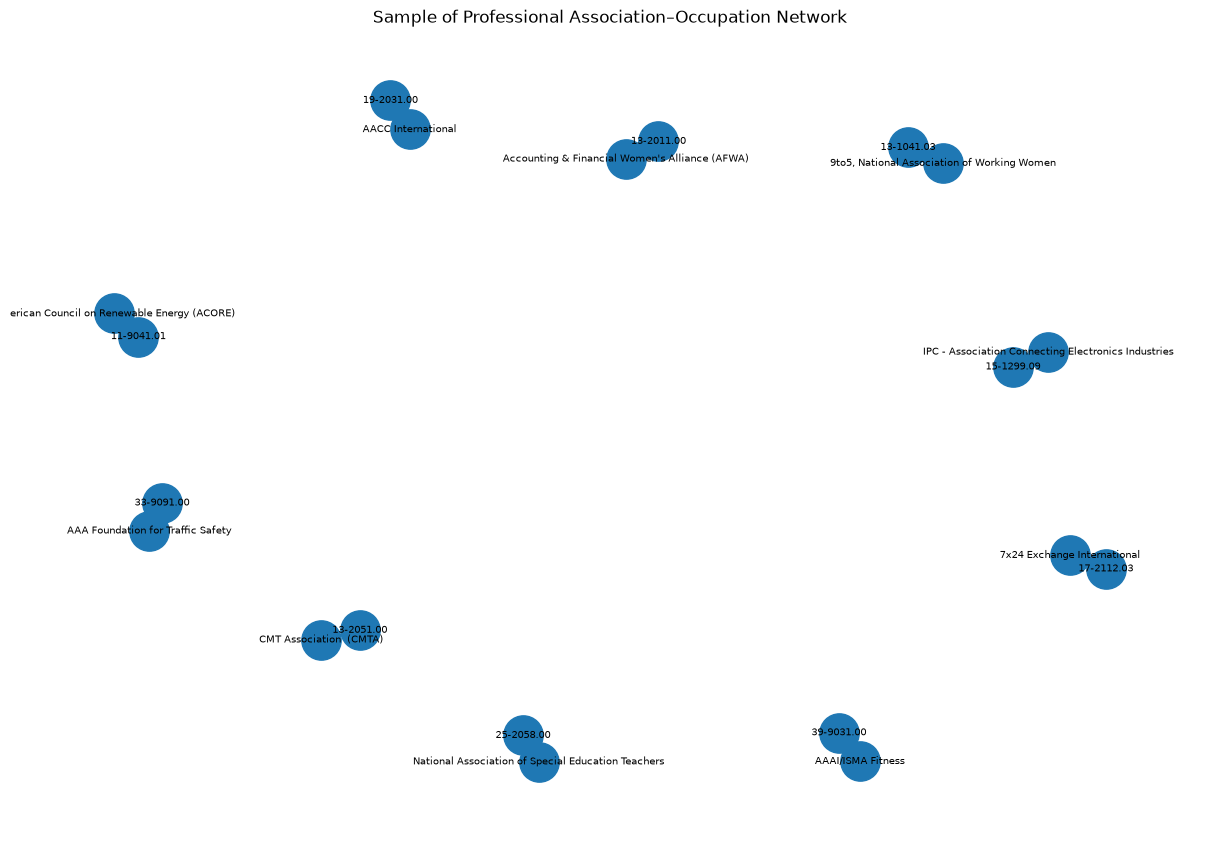

In [23]:
import matplotlib.pyplot as plt

# Select the first 10 associations as a small sample.
sample_associations = list(network_df["association"].unique())[:10]

# Start with those association nodes.
sample_nodes = set(sample_associations)

# Add every occupation connected to the sampled associations.
for association in sample_associations:
    sample_nodes.update(G.neighbors(association))

# Create a smaller graph containing only the selected nodes.
sample_G = G.subgraph(sample_nodes)

# Draw the sample network.
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(sample_G, seed=42)

nx.draw(
    sample_G,
    pos,
    with_labels=True,
    node_size=800,
    font_size=7
)

plt.title("Sample of Professional Association–Occupation Network")
plt.show()


# 17. Measure node importance with degree

**Degree** is the number of connections a node has.

In this project:
- An occupation with a high degree is connected to many professional associations.
- An association with a high degree is connected to many occupations.

This is the first definition of network importance: 
**how many direct connections does a node have?**


In [26]:
degree = dict(G.degree())

# Keep only association nodes and their degree values.
association_degree = {
    node: degree[node]
    for node in G.nodes
    if G.nodes[node]["node_type"] == "association"
}

# Keep only occupation nodes and their degree values.
occupation_degree = {
    node: degree[node]
    for node in G.nodes
    if G.nodes[node]["node_type"] == "occupation"
}


## 18. Find the occupations with the most connections

We sort occupations by degree from highest to lowest and keep the top 10.

These are the occupation nodes that are connected to the largest number of professional associations.


In [27]:
top_occupations = sorted(
    occupation_degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

for occupation, connections in top_occupations:
    print(occupation, "→", connections, "associations")


29-1141.00 → 59 associations
29-1229.00 → 37 associations
23-1011.00 → 35 associations
11-9111.00 → 33 associations
13-1199.00 → 27 associations
11-2021.00 → 27 associations
11-9033.00 → 26 associations
13-2011.00 → 25 associations
19-3011.00 → 25 associations
29-1249.00 → 23 associations


## 19. Find the associations with the most occupation connections

This does the same thing on the association side of the network.

Because the dataset is very sparse on the association side, most associations are connected to only one occupation. We will use this result later when interpreting the network.


In [28]:
top_associations = sorted(
    association_degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

for association, connections in top_associations:
    print(association, "→", connections, "occupations")


American Clean Power (ACP) → 2 occupations
Accounting & Financial Women's Alliance (AFWA) → 1 occupations
American Council on Renewable Energy (ACORE) → 1 occupations
CMT Association  (CMTA) → 1 occupations
IPC - Association Connecting Electronics Industries → 1 occupations
National Association of Special Education Teachers → 1 occupations
7x24 Exchange International → 1 occupations
9to5, National Association of Working Women → 1 occupations
AAA Foundation for Traffic Safety → 1 occupations
AAAI/ISMA Fitness → 1 occupations


## 20. Save the top occupation codes

This creates a list containing the O*NET codes for the top occupations.

We can use this list to inspect the original dataset and later match the codes to readable occupation names.


In [29]:
top_occupation_codes = [occupation for occupation, connections in top_occupations]

print(top_occupation_codes)


['29-1141.00', '29-1229.00', '23-1011.00', '11-9111.00', '13-1199.00', '11-2021.00', '11-9033.00', '13-2011.00', '19-3011.00', '29-1249.00']


In [30]:
# Show the top occupation codes found in the original dataset.
df[df["onet"].isin(top_occupation_codes)][["onet"]].drop_duplicates().sort_values("onet")


,onet
390,11-2021.00
75,11-9033.00
15,11-9111.00
344,13-1199.00
0,13-2011.00
92,19-3011.00
57,23-1011.00
24,29-1141.00
65,29-1229.00
150,29-1249.00


## 21. Visualize the top occupations

This bar chart makes the degree results easier to interpret.

The longer the bar, the more professional associations are connected to that occupation.


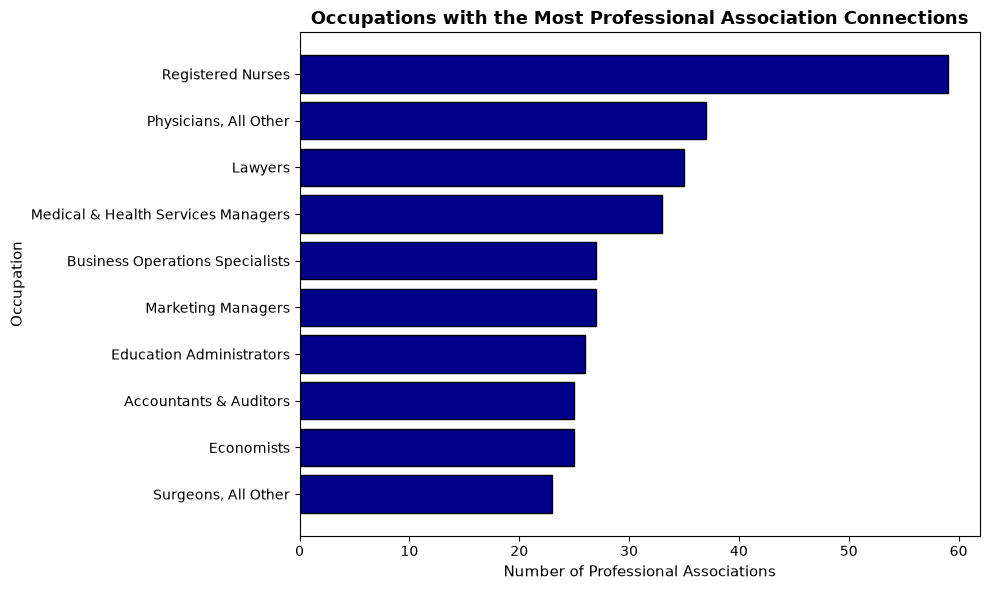

In [46]:
# Mapping dictionary to convert O*NET codes to readable job titles
occupation_names = {
    '29-1141.00': 'Registered Nurses',
    '29-1229.00': 'Physicians, All Other',
    '23-1011.00': 'Lawyers',
    '11-9111.00': 'Medical & Health Services Managers',
    '13-1199.00': 'Business Operations Specialists',
    '11-2021.00': 'Marketing Managers',
    '11-9033.00': 'Education Administrators',
    '13-2011.00': 'Accountants & Auditors',
    '19-3011.00': 'Economists',
    '29-1249.00': 'Surgeons, All Other'
}

top = top_occupations

# Extract readable titles using the dictionary (falls back to code if missing)
labels = [occupation_names.get(x[0], x[0]) for x in top]
values = [x[1] for x in top]

plt.figure(figsize=(10, 6))

# Plot horizontal bars with readable labels
plt.barh(labels[::-1], values[::-1], color='darkblue', edgecolor='black')

plt.xlabel("Number of Professional Associations", fontsize=11)
plt.ylabel("Occupation", fontsize=11)
plt.title("Occupations with the Most Professional Association Connections", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# 22. Degree centrality

**Degree centrality** is a standardized version of degree.

Instead of only reporting the number of connections, NetworkX expresses the number relative to the possible connections in the graph.

We calculate it for every node, then examine occupations and associations separately.


In [32]:
degree_centrality = nx.degree_centrality(G)


In [33]:
# Rank occupation nodes by degree centrality.
top_occupation_centrality = sorted(
    [
        (node, degree_centrality[node])
        for node in occupation_degree
    ],
    key=lambda x: x[1],
    reverse=True
)[:10]

for occupation, score in top_occupation_centrality:
    print(occupation, "→", round(score, 4))


29-1141.00 → 0.0192
29-1229.00 → 0.012
23-1011.00 → 0.0114
11-9111.00 → 0.0107
13-1199.00 → 0.0088
11-2021.00 → 0.0088
11-9033.00 → 0.0085
13-2011.00 → 0.0081
19-3011.00 → 0.0081
29-1249.00 → 0.0075


In [34]:
# Rank association nodes by degree centrality.
top_association_centrality = sorted(
    [
        (node, degree_centrality[node])
        for node in association_degree
    ],
    key=lambda x: x[1],
    reverse=True
)[:10]

for association, score in top_association_centrality:
    print(association, "→", round(score, 4))


American Clean Power (ACP) → 0.0007
Accounting & Financial Women's Alliance (AFWA) → 0.0003
American Council on Renewable Energy (ACORE) → 0.0003
CMT Association  (CMTA) → 0.0003
IPC - Association Connecting Electronics Industries → 0.0003
National Association of Special Education Teachers → 0.0003
7x24 Exchange International → 0.0003
9to5, National Association of Working Women → 0.0003
AAA Foundation for Traffic Safety → 0.0003
AAAI/ISMA Fitness → 0.0003


# 23. Betweenness centrality

**Betweenness centrality** measures how often a node appears on shortest paths between other nodes.

It is useful as a second lens for importance because a node can be important not only because it has many direct connections, but also because it can connect different parts of a network.

For this dataset, we should be careful with interpretation: the network is very sparse, so most associations have betweenness of zero.


In [35]:
betweenness = nx.betweenness_centrality(G)


### Associations with the highest betweenness

In [36]:
top_association_betweenness = sorted(
    [
        (node, betweenness[node])
        for node in association_degree
    ],
    key=lambda x: x[1],
    reverse=True
)[:10]

for association, score in top_association_betweenness:
    print(association, "→", round(score, 6))


American Clean Power (ACP) → 1e-06
Accounting & Financial Women's Alliance (AFWA) → 0.0
American Council on Renewable Energy (ACORE) → 0.0
CMT Association  (CMTA) → 0.0
IPC - Association Connecting Electronics Industries → 0.0
National Association of Special Education Teachers → 0.0
7x24 Exchange International → 0.0
9to5, National Association of Working Women → 0.0
AAA Foundation for Traffic Safety → 0.0
AAAI/ISMA Fitness → 0.0


### Occupations with the highest betweenness

In [37]:
top_occupation_betweenness = sorted(
    [
        (node, betweenness[node])
        for node in occupation_degree
    ],
    key=lambda x: x[1],
    reverse=True
)[:10]

for occupation, score in top_occupation_betweenness:
    print(occupation, "→", round(score, 6))


29-1141.00 → 0.000362
29-1229.00 → 0.000141
23-1011.00 → 0.000126
11-9111.00 → 0.000112
13-1199.00 → 7.4e-05
11-2021.00 → 7.4e-05
11-9033.00 → 6.9e-05
13-2011.00 → 6.4e-05
19-3011.00 → 6.4e-05
29-1249.00 → 5.4e-05


## 24. Create a final results table

This table combines the two importance measures for the top 10 occupations:
- number of direct association connections,
- degree centrality,
- betweenness centrality.

This is useful for the Medium post because it puts the main results in one place.


In [38]:
results = []

for occupation, connections in top_occupations:
    results.append({
        "O*NET Code": occupation,
        "Connections": connections,
        "Degree Centrality": round(degree_centrality[occupation], 4),
        "Betweenness Centrality": round(betweenness[occupation], 6)
    })

results_df = pd.DataFrame(results)

results_df


,O*NET Code,Connections,Degree Centrality,Betweenness Centrality
0,29-1141.00,59,0.0192,0.000362
1,29-1229.00,37,0.0120,0.000141
2,23-1011.00,35,0.0114,0.000126
3,11-9111.00,33,0.0107,0.000112
4,13-1199.00,27,0.0088,0.000074
5,11-2021.00,27,0.0088,0.000074
6,11-9033.00,26,0.0085,0.000069
7,13-2011.00,25,0.0081,0.000064
8,19-3011.00,25,0.0081,0.000064
9,29-1249.00,23,0.0075,0.000054


## 25. Visualize betweenness centrality

This chart shows the occupations with the highest betweenness scores.

If the same occupations appear near the top of both the degree and betweenness analyses, that means the two measures are identifying similar parts of this particular network.


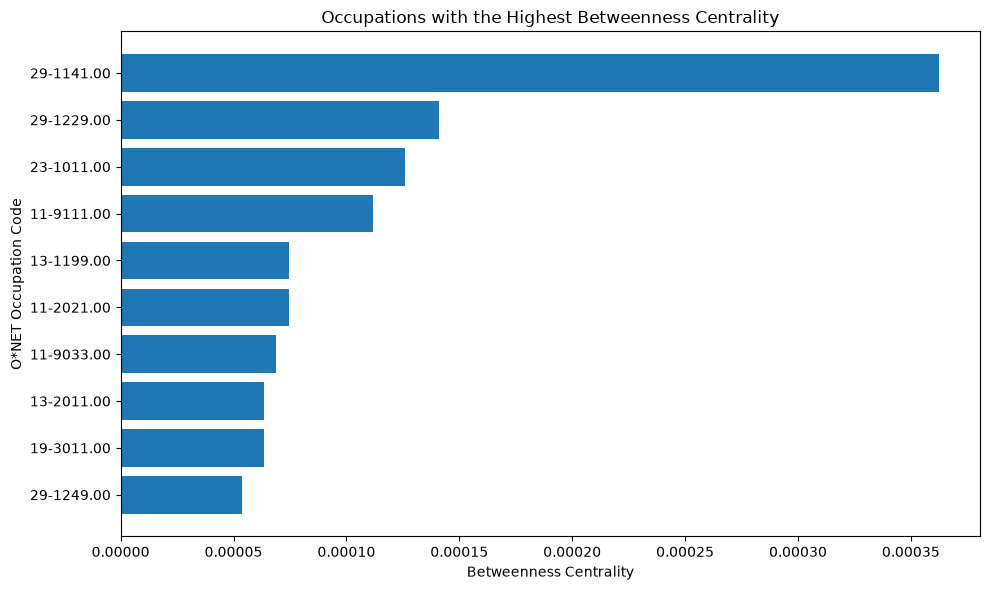

In [39]:
top = top_occupation_betweenness[:10]

codes = [x[0] for x in top]
values = [x[1] for x in top]

plt.figure(figsize=(10, 6))
plt.barh(codes[::-1], values[::-1])

plt.xlabel("Betweenness Centrality")
plt.ylabel("O*NET Occupation Code")
plt.title("Occupations with the Highest Betweenness Centrality")

plt.tight_layout()
plt.show()


## 26. Inspect the top three occupations

Network metrics tell us *which* occupation nodes are highly connected, but we also want to understand what those connections actually represent.

The following code prints every professional association connected to the top three occupations.


In [40]:
for occupation in top_occupations[:3]:
    print("\n", occupation[0], "—", occupation[1], "associations")

    connected = list(G.neighbors(occupation[0]))

    for association in connected:
        print("  -", association)



 29-1141.00 — 59 associations
  - AMDA - Dedicated to Long Term Care Medicine
  - ANA Enterprise (ANA)
  - Academy of Lactation Policy and Practice
  - American Academy of Ambulatory Care Nursing (AAACN)
  - American Assisted Living Nurses Association (AALNA)
  - American Association of Legal Nurse Consultants (AALNC)
  - American Association of Managed Care Nurses, Inc.
  - American Association of Nurse Life Care Planners
  - American Board of Certification for Gastroenterology Nurses (ABCGN)
  - American Board of Managed Care Nursing (ABMCN)
  - American Holistic Nurses' Association (AHNA)
  - American Nephrology Nurses Association (ANNA)
  - American Organization of Nurse Executives
  - American Psychiatric Nurses Association (APNA)
  - American Society for Ophthalmic Registered Nurses (ASORN)
  - American Society of PeriAnesthesia Nurses (ASPN)
  - American Society of Plastic Surgical Nurses (ASPSN)
  - Association for the Health Care Environment  (AHE)
  - Association of Nurses i

## 27. Find associations connected to multiple occupations

This directly answers the second part of our research question.

We look for associations with a degree greater than 1.

Because most associations in this dataset appear only once, this is also a useful check of how sparse the association side of the network is.


In [41]:
multi_occupation_associations = [
    (association, degree)
    for association, degree in association_degree.items()
    if degree > 1
]

multi_occupation_associations = sorted(
    multi_occupation_associations,
    key=lambda x: x[1],
    reverse=True
)

print("Associations connected to more than one occupation:")
print("Number:", len(multi_occupation_associations))

for association, connections in multi_occupation_associations:
    print(association, "→", connections, "occupations")


Associations connected to more than one occupation:
Number: 1
American Clean Power (ACP) → 2 occupations


# 28. Optional: inspect the occupations for multi-occupation associations

If the previous section finds any associations connected to more than one occupation, this cell shows exactly which occupation codes they connect to.

This is helpful when writing the interpretation because we can describe the relationship using the actual data instead of guessing.


In [42]:
for association, connections in multi_occupation_associations:
    print(f"\n{association} → {connections} occupations")
    for occupation in G.neighbors(association):
        print("  -", occupation)



American Clean Power (ACP) → 2 occupations
  - 17-2199.10
  - 11-9199.09
